In [1]:
%%capture
!pip install beir sentence-transformers rank_bm25 faiss-cpu


In [2]:
import math, time, os, warnings
warnings.filterwarnings("ignore")

from dataclasses import dataclass, field
from typing import Dict, List
import numpy as np

# ── Configuration ────────────────────────────────────────────────────────
DATASETS      = ["nfcorpus", "scifact", "trec-covid", "fiqa"]
SPLIT         = "test"
TOP_K         = 10
RERANK_POOL   = 50
BI_ENCODER    = "all-MiniLM-L6-v2"
CROSS_ENCODER = "cross-encoder/ms-marco-MiniLM-L-6-v2"
USE_FAISS     = False                  # set True for corpora > 50k docs
BATCH_SIZE    = 64

print(f"Config → datasets={DATASETS}  split={SPLIT}  top_k={TOP_K}")
print(f"         bi-encoder={BI_ENCODER}")


Config → datasets=['nfcorpus', 'scifact', 'trec-covid', 'fiqa']  split=test  top_k=10
         bi-encoder=all-MiniLM-L6-v2


In [3]:
import os, zipfile, requests
from beir.datasets.data_loader import GenericDataLoader

DATA_DIR = "./datasets"
os.makedirs(DATA_DIR, exist_ok=True)

def load_beir_dataset(dataset_name: str, split: str = SPLIT):
    """Download (if needed) and load a BEIR dataset; returns corpus, queries, qrels."""
    data_path = os.path.join(DATA_DIR, dataset_name)
    if not os.path.isdir(data_path):
        url      = f"https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/{dataset_name}.zip"
        zip_path = os.path.join(DATA_DIR, f"{dataset_name}.zip")
        print(f"Downloading {dataset_name} …")
        r = requests.get(url, stream=True)
        r.raise_for_status()
        with open(zip_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(DATA_DIR)
    else:
        print(f"Using cached {dataset_name}")
    corpus, queries, qrels = GenericDataLoader(data_folder=data_path).load(split=split)
    print(f"  → {len(corpus):,} docs | {len(queries):,} queries | "
          f"{sum(len(v) for v in qrels.values()):,} qrels")
    return corpus, queries, qrels

print("load_beir_dataset() ready.")


load_beir_dataset() ready.


In [4]:
import random
random.seed(42)

# Load nfcorpus for a quick data sanity-check before the main loop
corpus, queries, qrels = load_beir_dataset("nfcorpus")

sample_doc_id = random.choice(list(corpus.keys()))
doc = corpus[sample_doc_id]
print("── Sample document ──────────────────────────────────────────")
print(f"ID    : {sample_doc_id}")
print(f"Title : {doc['title']}")
print(f"Text  : {doc['text'][:300]} …")

sample_qid = random.choice(list(qrels.keys()))
print("\n── Sample query & qrels ─────────────────────────────────────")
print(f"Query : {queries[sample_qid]}")
print(f"Relevant doc IDs: {list(qrels[sample_qid].keys())[:5]}")

doc_lens = [len(d["text"].split()) for d in corpus.values()]
print("\n── Corpus stats ─────────────────────────────────────────────")
print(f"  Avg doc length : {np.mean(doc_lens):.0f} tokens")
print(f"  Max doc length : {np.max(doc_lens)} tokens")
print(f"  Avg relevant/q : {np.mean([len(v) for v in qrels.values()]):.1f}")


  0%|          | 0/3633 [00:00<?, ?it/s]

  → 3,633 docs | 323 queries | 12,334 qrels
── Sample document ──────────────────────────────────────────
ID    : MED-4239
Title : A low-fat diet and/or strenuous exercise alters the IGF axis in vivo and reduces prostate tumor cell growth in vitro.
Text  : BACKGROUND: Prostate cancer is the most common solid-tumor cancer in US males but is rare in Asian males. When Asian men adopt the US lifestyle, clinical prostate cancer increases greatly. Epidemiological data from men in the US indicate that regular activity may reduce the risk for prostate cancer. …

── Sample query & qrels ─────────────────────────────────────
Query : avocados
Relevant doc IDs: ['MED-1463', 'MED-1454', 'MED-1455', 'MED-1456', 'MED-1457']

── Corpus stats ─────────────────────────────────────────────
  Avg doc length : 221 tokens
  Max doc length : 1460 tokens
  Avg relevant/q : 38.2


In [5]:
@dataclass
class RetrievalResult:
    query_id: str
    ranked_doc_ids: List[str]
    scores: List[float]

def get_relevant(qid: str) -> List[str]:
    """Returns relevant doc IDs; references the current global `qrels`."""
    return [doc_id for doc_id, score in qrels.get(qid, {}).items() if score > 0]

print("RetrievalResult and get_relevant() defined.")


RetrievalResult and get_relevant() defined.


In [6]:
def reciprocal_rank(ranked: List[str], relevant: List[str]) -> float:
    for rank, doc_id in enumerate(ranked, 1):
        if doc_id in relevant:
            return 1.0 / rank
    return 0.0

def recall_at_k(ranked: List[str], relevant: List[str], k: int) -> float:
    return len(set(ranked[:k]) & set(relevant)) / max(len(relevant), 1)

def precision_at_k(ranked: List[str], relevant: List[str], k: int) -> float:
    return len(set(ranked[:k]) & set(relevant)) / k if k else 0.0

def average_precision(ranked: List[str], relevant: List[str]) -> float:
    hits, total = 0, 0.0
    for rank, doc_id in enumerate(ranked, 1):
        if doc_id in relevant:
            hits += 1
            total += hits / rank
    return total / max(len(relevant), 1)

def ndcg_at_k(ranked: List[str], relevant: List[str], k: int) -> float:
    dcg  = sum(1/math.log2(r+1) for r, d in enumerate(ranked[:k], 1) if d in relevant)
    idcg = sum(1/math.log2(r+1) for r in range(1, min(len(relevant), k) + 1))
    return dcg / idcg if idcg else 0.0

def evaluate(results: List[RetrievalResult], k: int = TOP_K) -> Dict[str, float]:
    mrr, rec, prec, ap, ndcg = [], [], [], [], []
    for res in results:
        rel = get_relevant(res.query_id)
        if not rel:
            continue
        mrr.append(reciprocal_rank(res.ranked_doc_ids[:k], rel))
        rec.append(recall_at_k(res.ranked_doc_ids, rel, k))
        prec.append(precision_at_k(res.ranked_doc_ids, rel, k))
        ap.append(average_precision(res.ranked_doc_ids[:k], rel))
        ndcg.append(ndcg_at_k(res.ranked_doc_ids, rel, k))
    n = len(mrr)
    if n == 0:
        return {m: 0.0 for m in [f"MRR@{k}", f"Recall@{k}", f"P@{k}", f"MAP@{k}", f"NDCG@{k}"]} | {"N queries": 0}
    return {
        f"MRR@{k}":    round(sum(mrr)/n,  4),
        f"Recall@{k}": round(sum(rec)/n,  4),
        f"P@{k}":      round(sum(prec)/n, 4),
        f"MAP@{k}":    round(sum(ap)/n,   4),
        f"NDCG@{k}":   round(sum(ndcg)/n, 4),
        "N queries":   n,
    }

def per_query_ndcg(results: List[RetrievalResult], k: int = TOP_K) -> Dict[str, float]:
    """Returns {query_id: ndcg@k} for every query that has at least one relevant doc."""
    scores = {}
    for res in results:
        rel = get_relevant(res.query_id)
        if rel:
            scores[res.query_id] = ndcg_at_k(res.ranked_doc_ids, rel, k)
    return scores

def print_metrics(label: str, m: Dict):
    print(f"\n{'='*52}")
    print(f"  {label}")
    print(f"{'='*52}")
    for k, v in m.items():
        if isinstance(v, float):
            bar = "█" * int(v * 30)
            print(f"  {k:<14}  {v:.4f}  {bar}")
        else:
            print(f"  {k:<14}  {v}")

print("Evaluation functions ready.")


Evaluation functions ready.


In [7]:
from rank_bm25 import BM25Okapi

class BM25Retriever:
    def __init__(self, doc_ids: List[str], doc_texts: List[str], k1=1.5, b=0.75):
        self.doc_ids = doc_ids
        tokenized    = [t.lower().split() for t in doc_texts]
        self.bm25    = BM25Okapi(tokenized, k1=k1, b=b)
        print(f"[BM25] Indexed {len(doc_ids):,} documents")

    def retrieve(self, query_id: str, query_text: str, k: int = TOP_K) -> RetrievalResult:
        scores  = self.bm25.get_scores(query_text.lower().split())
        top_idx = np.argsort(scores)[::-1][:k]
        return RetrievalResult(query_id, [self.doc_ids[i] for i in top_idx], scores[top_idx].tolist())

    def retrieve_all(self, qids, qtexts, k=TOP_K):
        return [self.retrieve(qid, qt, k) for qid, qt in zip(qids, qtexts)]


In [8]:
from sentence_transformers import SentenceTransformer
# NOTE: faiss import is intentionally inside _build_faiss() so USE_FAISS=False
#       doesn't crash when faiss-cpu is unavailable

class DenseRetriever:
    def __init__(self, doc_ids: List[str], doc_texts: List[str],
                 model_name=BI_ENCODER, use_faiss=USE_FAISS):
        self.doc_ids   = doc_ids
        self.use_faiss = use_faiss

        print(f"[Dense] Loading model: {model_name}")
        self.model = SentenceTransformer(model_name)

        print(f"[Dense] Encoding {len(doc_ids):,} documents …")
        t0 = time.time()
        self.doc_embs = self.model.encode(
            doc_texts,
            batch_size=BATCH_SIZE,
            show_progress_bar=True,
            normalize_embeddings=True,
            convert_to_numpy=True,
        ).astype("float32")
        print(f"[Dense] Done in {time.time()-t0:.1f}s  |  dim={self.doc_embs.shape[1]}")

        if use_faiss:
            self._build_faiss()

    def _build_faiss(self):
        try:
            import faiss                   # FIX: moved here — only imported when needed
        except ImportError:
            raise ImportError("Run: pip install faiss-cpu")
        dim        = self.doc_embs.shape[1]
        self.index = faiss.IndexFlatIP(dim)
        self.index.add(self.doc_embs)
        print(f"[FAISS] Index built — {self.index.ntotal:,} vectors")

    def retrieve(self, query_id: str, query_text: str, k: int = TOP_K) -> RetrievalResult:
        q = self.model.encode([query_text], normalize_embeddings=True,
                               convert_to_numpy=True).astype("float32")
        if self.use_faiss:
            scores, idxs = self.index.search(q, k)
            scores, idxs = scores[0], idxs[0]
        else:
            scores = (self.doc_embs @ q.T).squeeze()
            idxs   = np.argsort(scores)[::-1][:k]
            scores = scores[idxs]
        return RetrievalResult(query_id, [self.doc_ids[i] for i in idxs], scores.tolist())

    def retrieve_all(self, qids, qtexts, k=TOP_K):
        q_embs = self.model.encode(
            list(qtexts),
            batch_size=BATCH_SIZE,
            normalize_embeddings=True,
            convert_to_numpy=True,
        ).astype("float32")
        if self.use_faiss:
            scores_mat, idxs_mat = self.index.search(q_embs, k)
            return [
                RetrievalResult(qid, [self.doc_ids[i] for i in idxs], scores.tolist())
                for qid, scores, idxs in zip(qids, scores_mat, idxs_mat)
            ]
        sim = self.doc_embs @ q_embs.T   # (n_docs, n_queries)
        results = []
        for j, qid in enumerate(qids):
            scores = sim[:, j]
            idxs   = np.argsort(scores)[::-1][:k]
            results.append(RetrievalResult(qid, [self.doc_ids[i] for i in idxs], scores[idxs].tolist()))
        return results


In [9]:
from sentence_transformers.cross_encoder import CrossEncoder

class CrossEncoderReranker:
    def __init__(self, model_name=CROSS_ENCODER):
        print(f"[Reranker] Loading: {model_name}")
        self.model = CrossEncoder(model_name)

    def rerank(self, query_id: str, query_text: str,
               first_stage: RetrievalResult, k: int = TOP_K) -> RetrievalResult:
        candidates = first_stage.ranked_doc_ids
        texts      = [corpus[d]["title"] + " " + corpus[d]["text"] for d in candidates]
        pairs      = [(query_text, t) for t in texts]
        scores     = self.model.predict(pairs)
        ranked_idx = np.argsort(scores)[::-1][:k]
        return RetrievalResult(
            query_id,
            [candidates[i] for i in ranked_idx],
            [float(scores[i]) for i in ranked_idx],
        )

    def rerank_all(self, qids, qtexts, first_stage_results, k=TOP_K):
        from tqdm import tqdm
        return [
            self.rerank(qid, qt, fs, k)
            for qid, qt, fs in tqdm(zip(qids, qtexts, first_stage_results), total=len(qids))
        ]

reranker = CrossEncoderReranker()


[Reranker] Loading: cross-encoder/ms-marco-MiniLM-L-6-v2


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

In [10]:
import pandas as pd

# ── Main Experiment Loop ──────────────────────────────────────────────────
# Runs BM25 / Dense / Dense+Rerank on every dataset in DATASETS.
# After each dataset the per-dataset head-to-head table is displayed.
# Results are stored for the cross-dataset summary and Wilcoxon cells below.

all_dataset_results = {}   # {dataset_name: {method_label: metrics_dict}}
all_dataset_ndcg    = {}   # {dataset_name: {method_label: {qid: ndcg_score}}}

for dataset_name in DATASETS:
    print(f"\n{'#'*62}")
    print(f"#  {dataset_name.upper()}")
    print(f"{'#'*62}")

    # Load dataset — updates the global corpus/queries/qrels used by get_relevant()
    corpus, queries, qrels = load_beir_dataset(dataset_name)

    corpus_ids   = list(corpus.keys())
    corpus_texts = [(corpus[d]["title"] + " " + corpus[d]["text"]).strip()
                    for d in corpus_ids]
    query_ids    = list(queries.keys())
    query_texts  = [queries[qid] for qid in query_ids]

    # ── BM25 ─────────────────────────────────────────────────────────────
    bm25_r   = BM25Retriever(corpus_ids, corpus_texts)
    bm25_res = bm25_r.retrieve_all(query_ids, query_texts, k=TOP_K)
    bm25_m   = evaluate(bm25_res)

    # ── Dense bi-encoder ─────────────────────────────────────────────────
    dense_r   = DenseRetriever(corpus_ids, corpus_texts)
    dense_res = dense_r.retrieve_all(query_ids, query_texts, k=TOP_K)
    dense_m   = evaluate(dense_res)

    # ── Dense + cross-encoder re-rank ────────────────────────────────────
    expanded     = dense_r.retrieve_all(query_ids, query_texts, k=RERANK_POOL)
    reranked_res = reranker.rerank_all(query_ids, query_texts, expanded, k=TOP_K)
    reranked_m   = evaluate(reranked_res)

    # ── Per-dataset head-to-head table ───────────────────────────────────
    hth = pd.DataFrame({
        "BM25":         bm25_m,
        "Dense":        dense_m,
        "Dense+Rerank": reranked_m,
    }).T
    metric_cols = [c for c in hth.columns if c != "N queries"]
    try:
        from IPython.display import display as _display
        _display(hth[metric_cols].astype(float).round(4).style
            .background_gradient(cmap="YlGn", axis=0)
            .format("{:.4f}")
            .set_caption(f"Metrics @{TOP_K}  |  {dataset_name}  |  {bm25_m['N queries']} queries"))
    except Exception:
        print(hth[metric_cols].to_string())

    # ── Store ─────────────────────────────────────────────────────────────
    all_dataset_results[dataset_name] = {
        "BM25":         bm25_m,
        "Dense":        dense_m,
        "Dense+Rerank": reranked_m,
    }
    all_dataset_ndcg[dataset_name] = {
        "BM25":         per_query_ndcg(bm25_res),
        "Dense":        per_query_ndcg(dense_res),
        "Dense+Rerank": per_query_ndcg(reranked_res),
    }

    # Keep last-dataset result variables accessible for the qualitative cells below
    bm25_results, dense_results, reranked_results = bm25_res, dense_res, reranked_res
    bm25_retriever, dense_retriever               = bm25_r, dense_r

print("\n✓ All datasets complete.")



##############################################################
#  NFCORPUS
##############################################################
Using cached nfcorpus


  0%|          | 0/3633 [00:00<?, ?it/s]

  → 3,633 docs | 323 queries | 12,334 qrels
[BM25] Indexed 3,633 documents
[Dense] Loading model: all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/901 [00:00<?, ?it/s]

[Dense] Done in 134.0s  |  dim=384


100%|██████████| 648/648 [02:36<00:00,  4.13it/s]


,MRR@10,Recall@10,P@10,MAP@10,NDCG@10
BM25,0.1985,0.2037,0.0446,0.1163,0.1591
Dense,0.4451,0.4413,0.1045,0.2914,0.3687
Dense+Rerank,0.4577,0.4627,0.1083,0.3089,0.3870



✓ All datasets complete.


In [11]:
# ── Cross-Dataset Summary ─────────────────────────────────────────────────
metric_cols = [f"MRR@{TOP_K}", f"Recall@{TOP_K}", f"P@{TOP_K}", f"MAP@{TOP_K}", f"NDCG@{TOP_K}"]

rows = []
for dataset_name, methods in all_dataset_results.items():
    for method, m in methods.items():
        row = {"Dataset": dataset_name, "Method": method}
        row.update({col: m[col] for col in metric_cols})
        rows.append(row)

summary_df = (
    pd.DataFrame(rows)
    .set_index(["Dataset", "Method"])
    [metric_cols]
    .astype(float)
    .round(4)
)

print("\n" + "="*70)
print("  Cross-Dataset Summary — All Methods")
print("="*70)
try:
    from IPython.display import display as _display
    _display(summary_df.style
        .background_gradient(cmap="YlGn", axis=0)
        .format("{:.4f}")
        .set_caption(f"Metrics @{TOP_K} — all datasets (rows = dataset × method)"))
except Exception:
    print(summary_df.to_string())



  Cross-Dataset Summary — All Methods


In [12]:
# ── Paired Wilcoxon Signed-Rank Tests ────────────────────────────────────
# Tests whether per-query NDCG@TOP_K differences between method pairs are
# statistically significant (two-sided, α = 0.05), run per dataset.
from scipy.stats import wilcoxon

print(f"Paired Wilcoxon Signed-Rank Tests — NDCG@{TOP_K}\n")
print(f"{'Dataset':<15}  {'Pair':<25}  {'W':>10}  {'p-value':>10}  Verdict")
print("-" * 82)

for dataset_name, ndcg_by_method in all_dataset_ndcg.items():
    bm25_d   = ndcg_by_method["BM25"]
    dense_d  = ndcg_by_method["Dense"]
    rerank_d = ndcg_by_method["Dense+Rerank"]

    # Align on queries present in all three score dicts
    common   = sorted(set(bm25_d) & set(dense_d) & set(rerank_d))
    bm25_v   = np.array([bm25_d[q]   for q in common])
    dense_v  = np.array([dense_d[q]  for q in common])
    rerank_v = np.array([rerank_d[q] for q in common])

    for pair_label, a, b in [
        ("BM25 ↔ Dense",         bm25_v,  dense_v),
        ("Dense ↔ Dense+Rerank", dense_v, rerank_v),
    ]:
        diff = b - a
        if np.any(diff != 0):
            stat, p = wilcoxon(diff, alternative="two-sided")
        else:
            stat, p = float("nan"), 1.0
        verdict = "significant (p<0.05)" if p < 0.05 else "not significant"
        print(f"{dataset_name:<15}  {pair_label:<25}  {stat:>10.1f}  {p:>10.4f}  {verdict}")
    print()


Paired Wilcoxon Signed-Rank Tests — NDCG@10

Dataset          Pair                                W     p-value  Verdict
----------------------------------------------------------------------------------
nfcorpus         BM25 ↔ Dense                   7261.0      0.0000  significant (p<0.05)
nfcorpus         Dense ↔ Dense+Rerank           8051.0      0.0338  significant (p<0.05)

scifact          BM25 ↔ Dense                   3499.5      0.0002  significant (p<0.05)
scifact          Dense ↔ Dense+Rerank           2506.5      0.0032  significant (p<0.05)

trec-covid       BM25 ↔ Dense                    534.5      0.7549  not significant
trec-covid       Dense ↔ Dense+Rerank             65.0      0.0000  significant (p<0.05)

fiqa             BM25 ↔ Dense                  12810.5      0.0000  significant (p<0.05)
fiqa             Dense ↔ Dense+Rerank          32416.0      0.1098  not significant



In [13]:
random.seed(0)                          # FIX: seed for reproducibility
sample_qid = random.choice(query_ids)
sample_qt  = queries[sample_qid]
rel_ids    = set(get_relevant(sample_qid))

print(f"Query  : {sample_qt}")
print(f"Relevant docs ({len(rel_ids)} total): {list(rel_ids)[:4]}\n")

for label, results in [
    ("BM25",         bm25_results),
    ("Dense",        dense_results),
    ("Dense+Rerank", reranked_results),
]:
    res  = next(r for r in results if r.query_id == sample_qid)
    hits = ["✓" if d in rel_ids else "✗" for d in res.ranked_doc_ids[:5]]
    print(f"[{label}] Top-5:")
    for rank, (doc_id, score, hit) in enumerate(zip(res.ranked_doc_ids[:5], res.scores[:5], hits), 1):
        title = corpus[doc_id]["title"][:60]
        print(f'  {rank}. [{hit}] ({score:.3f})  "{title}"')
    print()


Query  : Why can low volume move a stock price drastically?
Relevant docs (1 total): ['228983']

[BM25] Top-5:
  1. [✗] (23.898)  ""
  2. [✗] (23.416)  ""
  3. [✗] (22.736)  ""
  4. [✗] (22.630)  ""
  5. [✗] (21.293)  ""

[Dense] Top-5:
  1. [✗] (0.735)  ""
  2. [✗] (0.690)  ""
  3. [✗] (0.647)  ""
  4. [✗] (0.613)  ""
  5. [✗] (0.609)  ""

[Dense+Rerank] Top-5:
  1. [✗] (5.499)  ""
  2. [✗] (4.919)  ""
  3. [✗] (4.228)  ""
  4. [✗] (4.121)  ""
  5. [✗] (3.894)  ""



[Curve] Running k=100 retrieval for NDCG curve …


100%|██████████| 648/648 [03:49<00:00,  2.83it/s]


[Curve] Done.


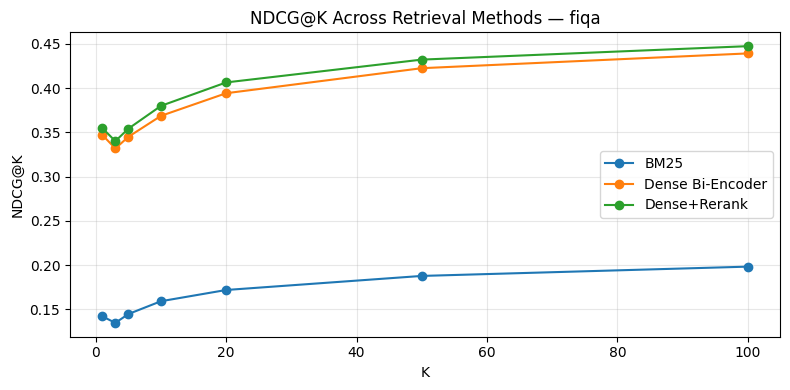

Saved: ndcg_curve.png


In [14]:
import matplotlib.pyplot as plt

CURVE_K = 100
ks      = [1, 3, 5, 10, 20, 50, 100]

print("[Curve] Running k=100 retrieval for NDCG curve …")
bm25_curve   = bm25_retriever.retrieve_all(query_ids, query_texts, k=CURVE_K)
dense_curve  = dense_retriever.retrieve_all(query_ids, query_texts, k=CURVE_K)
_pool_curve  = dense_retriever.retrieve_all(query_ids, query_texts, k=max(RERANK_POOL, CURVE_K))
rerank_curve = reranker.rerank_all(query_ids, query_texts, _pool_curve, k=CURVE_K)
print("[Curve] Done.")

def ndcg_curve(results, k_list):
    return [evaluate(results, k=k)[f"NDCG@{k}"] for k in k_list]

plt.figure(figsize=(8, 4))
for label, results in [
    ("BM25",            bm25_curve),
    ("Dense Bi-Encoder",dense_curve),
    ("Dense+Rerank",    rerank_curve),
]:
    plt.plot(ks, ndcg_curve(results, ks), marker="o", label=label)

plt.xlabel("K"); plt.ylabel("NDCG@K")
plt.title(f"NDCG@K Across Retrieval Methods — {dataset_name}")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig("ndcg_curve.png", dpi=150)
plt.show()
print("Saved: ndcg_curve.png")
